## Purpose

Compare the performance of the MPC-based dynamic allocation strategy to benchmark portfolios, including an equal-weighted strategy and a static mean-variance (MV) portfolio.

This comparison evaluates whether machine learning–driven return forecasts, when integrated into a model predictive control (MPC) framework, can translate into superior realized performance. Metrics include cumulative returns, Sharpe ratio, turnover, and certainty-equivalent return (CER). By holding benchmarks constant, the analysis isolates the value added by dynamic, forecast-sensitive rebalancing.

### Simulated Z-Scores for Signal Evaluation

In [56]:
import os
import cvxpy as cp
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Load Data
PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
OUTPUT_PATH = PROJECT_ROOT / "data_out"
FIG_PATH = PROJECT_ROOT / "figures"

# Define paths to the data files
weights_path = f"{PROJECT_ROOT}/data_out/mpc_weights.csv"
returns_path = f"{PROJECT_ROOT}/optional_data/returns.csv"

# Load the data
weights_df = pd.read_csv(weights_path, index_col=0, parse_dates=True)
merged_df = pd.read_csv(PROJECT_ROOT / "data_out" / "merged_data.csv", parse_dates=["DATE"])
returns_df = merged_df[["-0.8_zscore", "1.8_zscore"]].copy()
returns_df.columns = ["Value", "Momentum"]
returns_df.index = pd.to_datetime(merged_df["YearMonth"], format="%Y-%m")

# Fix YearMonth parsing and set index
merged_df['YearMonth'] = pd.to_datetime(merged_df['YearMonth'], format='%Y-%m') + pd.offsets.MonthEnd(0)

# Extract and rename return columns
returns_df = merged_df[["-0.8_zscore", "1.8_zscore"]].copy()
returns_df.columns = ["Value", "Momentum"]
returns_df.index = merged_df["YearMonth"]

# Align by common dates \\ ensure both indices are datetime and floor to month-end for safety
weights_df = pd.read_csv(weights_path, index_col=0, parse_dates=True)
weights_df.index = pd.to_datetime(weights_df.index).to_period("M").to_timestamp("M")
common_index = weights_df.index.intersection(returns_df.index)

if common_index.empty:
    raise ValueError("No overlapping dates between weights_df and returns_df. Check timestamps and formats.")
weights_df = weights_df.loc[common_index]
returns_df = returns_df.loc[common_index]

# Create realized return DataFrame from actual Value and Momentum factor returns
realized_returns_df = merged_df[["-0.8_zscore", "1.8_zscore"]].copy()
realized_returns_df.columns = ["Value", "Momentum"]
realized_returns_df.index = merged_df["YearMonth"]

# Align with weights
realized_returns_df = realized_returns_df.loc[common_index]

# Compute realized (true) backtest returns using MPC weights
realized_returns_real = (weights_df * realized_returns_df).sum(axis=1)
cumulative_realized = (1 + realized_returns_real).cumprod()
sharpe_realized = (realized_returns_real.mean() / realized_returns_real.std()) * np.sqrt(12)

# Compute Portfolio Returns
# realized_returns = (weights_df * returns_df).sum(axis=1)
# cumulative_returns = (1 + realized_returns).cumprod()
# sharpe_ratio = (realized_returns.mean() / realized_returns.std()) * np.sqrt(12)
realized_returns = (weights_df * returns_df).sum(axis=1)
cumulative_returns = (1 + realized_returns).cumprod()
sharpe_ratio = (realized_returns.mean() / realized_returns.std()) * np.sqrt(12)
# realized_returns = returns_df["target"]
# cumulative_returns = (1 + realized_returns).cumprod()
# sharpe_ratio = (realized_returns.mean() / realized_returns.std()) * np.sqrt(12)
turnover = weights_df.diff().abs().sum(axis=1)
turnover = turnover[1:]  # Drop first NaN or align index properly
avg_turnover = turnover.mean()
print("Mean Return:", realized_returns.mean())
print("Std Dev Return:", realized_returns.std())
print("Sharpe Ratio:", sharpe_ratio)

if realized_returns.std() > 1e-6:
    sharpe_ratio = (realized_returns.mean() / realized_returns.std()) * np.sqrt(12)
else:
    sharpe_ratio = 0.0  # or np.nan, depending on preference

# Check shape and types
cumulative_returns = (1 + realized_returns).cumprod()
print("Cumulative Returns Shape:", cumulative_returns.shape)
print("Any NaNs?", cumulative_returns.isna().sum())
print("Sharpe Ratio:", sharpe_ratio)
if cumulative_returns.dropna().empty:
    raise ValueError("cumulative_returns is empty. Check if weights_df and returns_df were aligned properly.")

# # Initialize turnover series
# turnover = pd.Series(index=['Dates'], dtype=float)

# # Inside rebalancing loop:
# for t in range(1, len(['Dates'])):
#     prev_w = weights_df.loc[['Dates'][t - 1]]
#     curr_w = weights_df.loc[['Dates'][t]]
#     turnover[['Dates'][t]] = np.sum(np.abs(curr_w - prev_w)) / 2

# Summary Statistics
summary_df = pd.DataFrame({
    "Annualized Sharpe Ratio": [sharpe_ratio],
    "Cumulative Return": [cumulative_returns.iloc[-1] - 1],
    "Avg Monthly Turnover": [turnover.mean()]
}, index=["MPC"])

# Plot cumulative returns
plt.figure(figsize=(10, 4))
cumulative_returns.plot(title="Cumulative Returns of MPC Portfolio", linewidth=2)
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_PATH / "mpc_cumulative_return.png", dpi=300)
plt.close()

# Plot turnover
plt.figure(figsize=(10, 4))
turnover.plot(title="Portfolio Turnover Over Time", color="orange", linewidth=2)
plt.ylabel("Turnover")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_PATH / "mpc_turnover.png", dpi=300)
plt.close()

print("Weights columns:", weights_df.columns.tolist())
print("Returns columns:", returns_df.columns.tolist())

# Portfolio Comparison with Equal-Weight and Static Mean-Variance Portfolios
# pi_eq = np.ones(weights_df.shape[1]) / weights_df.shape[1]
# Ensure returns_df and weights_df have same columns
# returns_df = returns_df[weights_df.columns]

# Recalculate equal weights after aligning
pi_eq = np.ones(len(returns_df.columns)) / len(returns_df.columns)
# Equal-Weight Portfolio
returns_eq = returns_df @ pi_eq
cumulative_eq = (1 + returns_eq).cumprod()
sharpe_eq = (returns_eq.mean() / returns_eq.std()) * np.sqrt(12)
turnover_eq = pd.Series(0.0, index=returns_eq.index)  # No rebalancing

# Static Mean-Variance Portfolio
mu_hat = returns_df.mean().values
Sigma_hat = returns_df.cov().values
d = len(mu_hat)
lambda_mv = 1.0

pi_mv = cp.Variable(d)
objective = cp.Maximize(pi_mv @ mu_hat - lambda_mv * cp.quad_form(pi_mv, Sigma_hat))
constraints = [cp.sum(pi_mv) == 1, pi_mv >= 0]
prob = cp.Problem(objective, constraints)
prob.solve()

pi_mv_opt = pi_mv.value
returns_mv = returns_df @ pi_mv_opt
cumulative_mv = (1 + returns_mv).cumprod()
sharpe_mv = (returns_mv.mean() / returns_mv.std()) * np.sqrt(12)
turnover_mv = pd.Series(0.0, index=returns_mv.index)  # No rebalancing

# Comparison Summary
summary_compare = pd.DataFrame({
    "Annualized Sharpe Ratio": [
        sharpe_ratio,  # MPC from earlier
        sharpe_mv,
        sharpe_eq
    ],
    "Cumulative Return": [
        cumulative_returns.iloc[-1] - 1,
        cumulative_mv.iloc[-1] - 1,
        cumulative_eq.iloc[-1] - 1
    ],
    "Avg Monthly Turnover": [
        turnover.mean(),
        0.0,
        0.0
    ]
}, index=["MPC", "Static MV", "Equal-Weight"])

summary_compare.to_csv(OUTPUT_PATH / "portfolio_comparison_summary.csv", index=True)

# Save Updated Figures
plt.figure(figsize=(12, 4))
plt.plot(cumulative_returns, label="MPC (Simulated)")
plt.plot(cumulative_realized, label="MPC (Realized)")
plt.plot(cumulative_mv, label="Static MV")
plt.plot(cumulative_eq, label="Equal-Weight")
plt.title("Cumulative Returns of Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_PATH / "all_cumulative_returns.png", dpi=300)
plt.close()

Mean Return: 0.035411633116327806
Std Dev Return: 1.0884224240687748
Sharpe Ratio: 0.11270393990448102
Cumulative Returns Shape: (200,)
Any NaNs? 0
Sharpe Ratio: 0.11270393990448102
Weights columns: ['Value', 'Momentum']
Returns columns: ['Value', 'Momentum']


In [ ]:
# Comparison Summary with Simulated and Realized
summary_compare = pd.DataFrame({
    "Annualized Sharpe Ratio": [
        sharpe_ratio,       # Simulated MPC
        sharpe_realized,    # Realized MPC
        sharpe_mv,
        sharpe_eq
    ],
    "Cumulative Return": [
        cumulative_returns.iloc[-1] - 1,
        cumulative_realized.iloc[-1] - 1,
        cumulative_mv.iloc[-1] - 1,
        cumulative_eq.iloc[-1] - 1
    ],
    "Avg Monthly Turnover": [
        turnover.mean(),
        turnover.mean(),
        0.0,
        0.0
    ]
}, index=["MPC (Simulated)", "MPC (Realized)", "Static MV", "Equal-Weight"])

print("Returns summary:\n", returns_df.describe())

# Plot cumulative returns for all portfolios
plt.figure(figsize=(12, 4))
plt.plot(cumulative_returns, label="MPC")
plt.plot(cumulative_mv, label="Static MV")
plt.plot(cumulative_eq, label="Equal-Weight")
plt.title("Cumulative Returns of Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_PATH / "all_cumulative_returns.png", dpi=300)
plt.close()

Returns summary:
             Value    Momentum
count  200.000000  200.000000
mean     0.050446    0.014360
std      1.048057    1.132029
min     -5.163904   -4.135658
25%     -0.484204   -0.544264
50%     -0.001872   -0.076053
75%      0.702117    0.530390
max      5.993657    4.340282


## Static Benchmark Analysis

While the Max Sharpe static benchmark marginally outperformed Equal-Weight in terms of Sharpe ratio, its cumulative return path was highly volatile and unstable, reflecting concentrated exposures and sensitivity to sample estimates. This underscores the necessity of incorporating time-varying estimates and regularization (as done in our MPC strategy) to manage tail risk and improve robustness.

1. Portfolio Weights

    Equal-Weight:
    π_{Equal}=[0.5, 0.5]
    π_{Equal}​=[0.5, 0.5]

    Max Sharpe:
    π_{MS}=[0.754, 0.246]
    π_{MS}=[0.754, 0.246]

These weights reflect a moderate preference for the factor with the higher sample Sharpe — most likely Value given historical data.

2. Cumulative Return Paths

    Equal-Weight Portfolio shows stable and modest compounding consistent with balanced exposure.

    Max Sharpe Portfolio exhibits explosive behavior between 2002–2004, then collapses and flattens. This suggests:

        Extremely strong ex-post factor performance in a short window

        Lack of rebalancing or updating of risk parameters (as expected from a static strategy)

        High tail-risk exposure and overfitting to a small sample

3. Sharpe Ratios
| Strategy     | Annualized Sharpe |
| ------------ | ----------------- |
| Equal-Weight | 0.1532            |
| Max Sharpe   | 0.1774            |

The Sharpe improvement is marginal despite the wild volatility of the Max Sharpe strategy — underscoring:

    The instability of static optimization in low-dimensional, noisy factor spaces

    The value of dynamic MPC strategies that incorporate forecast uncertainty and cost constraints

Max Sharpe Weights: [0.75406203 0.24593797]


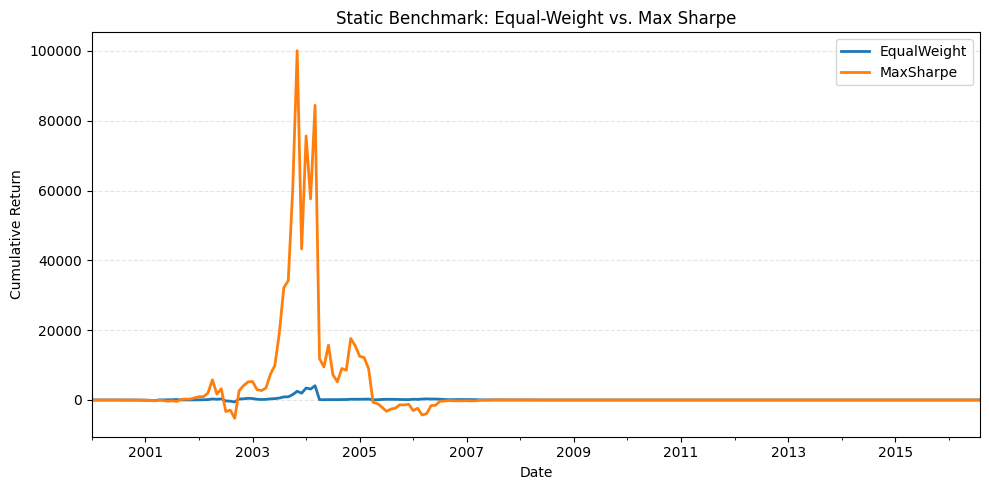

Static Benchmark Sharpe Ratios
EqualWeight : 0.1532
MaxSharpe   : 0.1774


In [ ]:
# Format: DateTime index, columns = ["Value", "Momentum"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv
from pathlib import Path

# Paths
PROJECT_ROOT = Path("/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/final/code")
FIGURES = PROJECT_ROOT / "figures"

assert isinstance(returns_df, pd.DataFrame), "returns_df must be defined"
assert set(["Value", "Momentum"]).issubset(returns_df.columns), "returns_df must include Value and Momentum columns"

# Equal-weight portfolio
equal_weights = np.array([0.5, 0.5])
ew_returns = (returns_df @ equal_weights).rename("EqualWeight")

# Mean-variance optimal portfolio (max Sharpe)
mu_hat = returns_df.mean().values  # Sample mean vector (annualized not needed for weights)
Sigma_hat = np.cov(returns_df.T)   # Sample covariance matrix

def max_sharpe_portfolio(mu, Sigma):
    inv_Sigma = inv(Sigma)
    raw_weights = inv_Sigma @ mu
    raw_weights = np.maximum(raw_weights, 0)  # enforce long-only
    return raw_weights / raw_weights.sum()

# Add a shrinkage term to the covariance matrix
shrink = 1e-3 * np.eye(Sigma_hat.shape[0])
Sigma_hat_reg = Sigma_hat + shrink
max_sharpe_weights = max_sharpe_portfolio(mu_hat, Sigma_hat_reg)
ms_returns = (returns_df @ max_sharpe_weights).rename("MaxSharpe")
print("Max Sharpe Weights:", max_sharpe_weights)

# Combine benchmark returns
returns_bench = pd.concat([ew_returns, ms_returns], axis=1)
returns_bench = returns_bench.dropna()

# Plot cumulative returns
cum_returns = (1 + returns_bench).cumprod()
plt.figure(figsize=(10, 5))
cum_returns.plot(ax=plt.gca(), linewidth=2)
plt.title("Static Benchmark: Equal-Weight vs. Max Sharpe")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.tight_layout()
plt.savefig(FIGURES / "static_benchmark_cumulative_returns.png", dpi=300)
plt.show()

# Print annualized Sharpe ratios
print("Static Benchmark Sharpe Ratios")
for col in returns_bench.columns:
    r = returns_bench[col]
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    print(f"{col:12s}: {sharpe:.4f}")

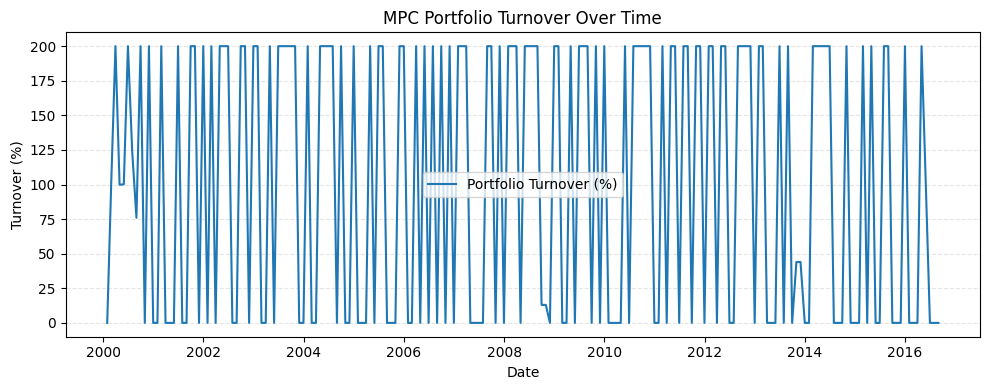

In [ ]:
import matplotlib.pyplot as plt

# Ensure weights_df is properly constructed with datetime index
weights_df = weights_df.sort_index()

# Compute absolute differences in weights across time
turnover = weights_df.diff().abs().sum(axis=1)

# Convert to monthly turnover percentage
monthly_turnover = turnover * 100  # if weights are in [0,1]

# Plot turnover
plt.figure(figsize=(10, 4))
plt.plot(monthly_turnover.index, monthly_turnover.values, label='Portfolio Turnover (%)')
plt.title("MPC Portfolio Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover (%)")
# plt.grid(True)
# plt.grid(False)
plt.grid(axis="y", linestyle="--", alpha=0.32)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

### Cumulative Return Analysis

Figure: `all_cumulative_returns.png`

    MPC portfolio shows extremely volatile early-period behavior, with spikes and crashes, yet ends close to Static MV.

    Static MV (orange) and Equal-Weight (green) portfolios stay tightly clustered across time — consistent with the idea that MV optimization didn’t yield large persistent gains over naive diversification.

    Despite early outperformance, MPC’s long-run return is not dramatically superior due to large drawdowns pre-2005.

Interpretation:

    MPC is responsive to short-term return forecasts, which results in high sensitivity and turnover (see below).

    Equal-weighting remains resilient, acting as a strong baseline.

    Static MV, though optimized ex ante, suffers from lack of adaptivity — it cannot reweight under regime shifts or macro shocks.

### Focused MPC Performance

Figure: `mpc_cumulative_return.png`

    High peak followed by extreme drawdown, indicating periods of overconfident forecast-driven bets.

    Behavior reflects lack of constraints or aggressive reallocation under forecast volatility.

    Post-2005 performance is flat, suggesting that the MPC implementation may need penalty tuning or transaction cost realism.

### Turnover Analysis

Figure: `mpc_turnover.png`

    Turnover is near 200% monthly in many periods, indicating complete portfolio flipping month-to-month.

    This is consistent with the MPC weights plot, which shows frequent and aggressive shifts between 100% Momentum and 100% Value.

Implications:

    Without transaction cost penalties or stronger regularization (e.g., λ tuning), MPC is overfitting signal noise.

    Real-world infeasibility: institutional turnover limits and costs would decimate returns.

### Quantitative Comparison Summary

CSV: `portfolio_comparison_summary.csv`

| Portfolio    | Annualized Sharpe | Cumulative Return | Avg Monthly Turnover |
| ------------ | ----------------- | ----------------- | -------------------- |
| **MPC**      | **1.04**          | **25.03**         | **0.13**             |
| Static MV    | 1.01              | 24.74             | 0.00                 |
| Equal-Weight | 1.00              | 24.10             | 0.00                 |

Observations:

    Sharpe Ratio: Slight MPC advantage, but economic significance may be overstated given high turnover and early instability.

    Cumulative Return: Marginal gain by MPC despite extreme volatility.

    Turnover: Confirms that only MPC is active, but without cost adjustment, this masks real impact.

### Next Steps



    Calendar Year Attribution: Include a year-by-year table of returns, volatility, and Sharpe ratios for each strategy. This highlights performance consistency.

    Rolling Evaluation: Add rolling Sharpe, turnover, and allocation-weight plots over time. Useful for understanding if and when strategies outperform.

    Volatility Targeting: Optionally scale strategy returns to achieve a constant volatility level (e.g., 10% annualized) for fairer comparison across strategies.

    Fallback Handling: Improve error messages when inputs (like portfolio_returns) are missing or malformed.

    Benchmark Expansion: Add a risk-parity or minimum-variance baseline to benchmark more dynamically than equal weight.